<a href="https://www.kaggle.com/code/hisyamsyafaraditya/final-project-machine-learning?scriptVersionId=323893214" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Load Dataset

## Training Set

In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/train.csv")
display(train_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


## Testing Set

In [3]:
test_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/test.csv")
display(test_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


# Data Understanding

## Training Set

In [4]:
print("Train Dataset Information")
print(f"Jumlah baris : {train_df.shape[0]}")
print(f"Jumlah baris : {train_df.shape[1]}")

Train Dataset Information
Jumlah baris : 59598
Jumlah baris : 24


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

## Testing Set

In [6]:
print("Test Dataset Information")
print(f"Jumlah baris : {test_df.shape[0]}")
print(f"Jumlah baris : {test_df.shape[1]}")

Test Dataset Information
Jumlah baris : 14900
Jumlah baris : 24


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Number of Dependents  

# Exploratory Data Analysis (EDA)

## Missing Value Check

In [8]:
print(train_df.isnull().sum())

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64


## Duplicate Check

In [9]:
print("Duplicate rows :", train_df.duplicated().sum())

Duplicate rows : 0


## Class Distribution

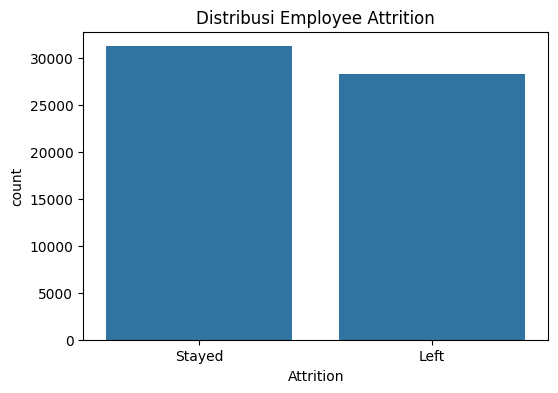

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Attrition'
)

plt.title('Distribusi Employee Attrition')
plt.show()

In [11]:
print(train_df['Attrition'].value_counts())
print(train_df['Attrition'].value_counts(normalize=True)*100)

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64
Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


## Numerical Feature Distribution

In [12]:
numerical_cols = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions',
    'Distance from Home',
    'Company Tenure',
    'Number of Dependents'
]

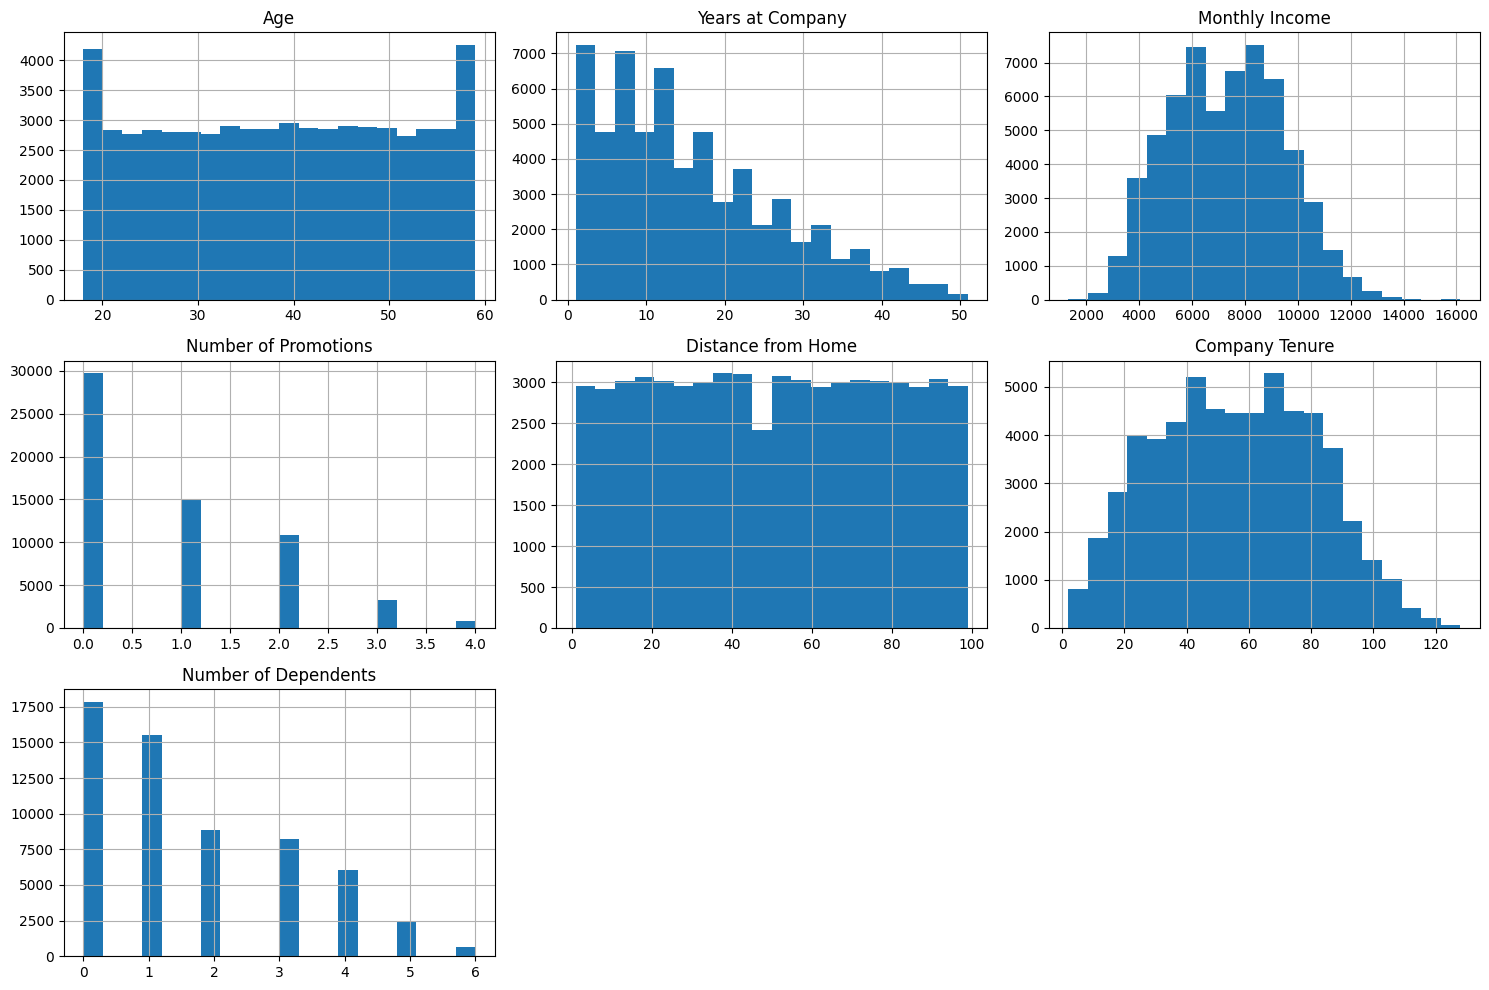

In [13]:
train_df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

## Relationship Between Features and Target

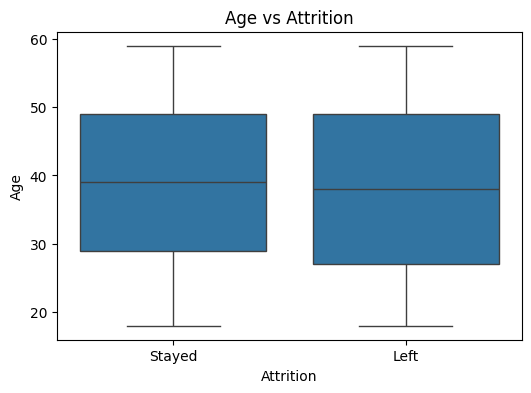

In [14]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Age'
)

plt.title('Age vs Attrition')
plt.show()

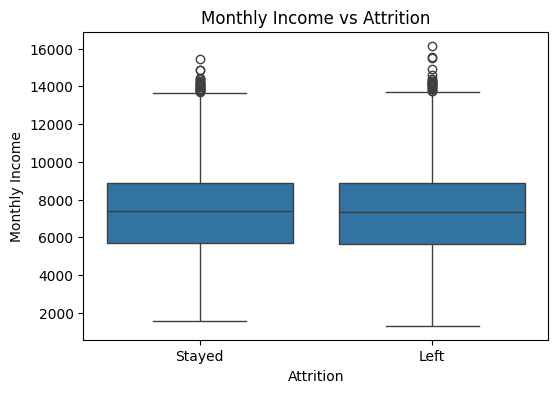

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Monthly Income'
)

plt.title('Monthly Income vs Attrition')
plt.show()

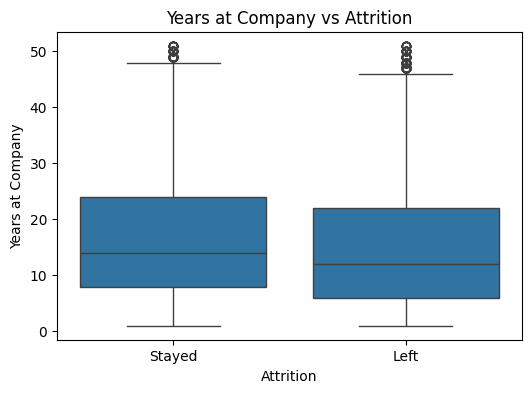

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Years at Company'
)

plt.title('Years at Company vs Attrition')
plt.show()

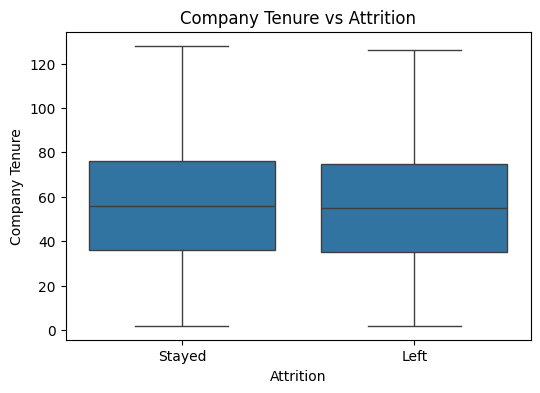

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Company Tenure'
)

plt.title('Company Tenure vs Attrition')
plt.show()

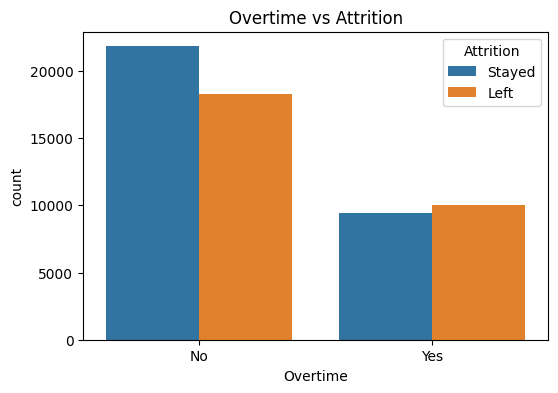

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Overtime',
    hue='Attrition'
)

plt.title('Overtime vs Attrition')
plt.show()

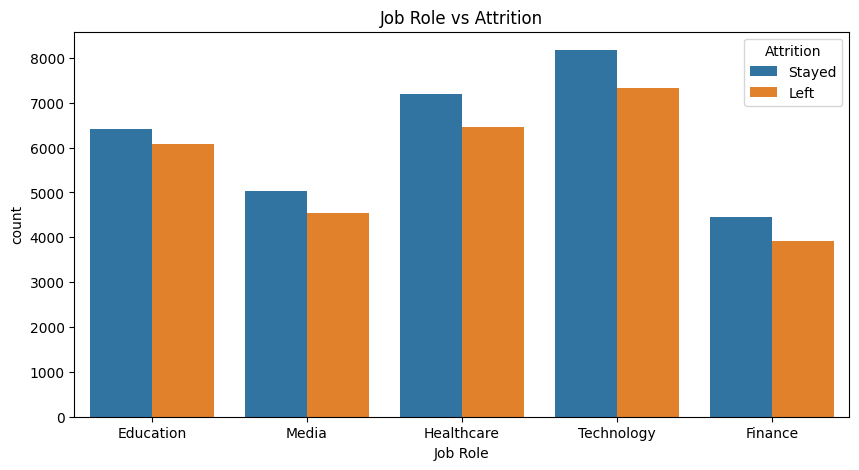

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    x='Job Role',
    hue='Attrition'
)

plt.title('Job Role vs Attrition')
plt.show()

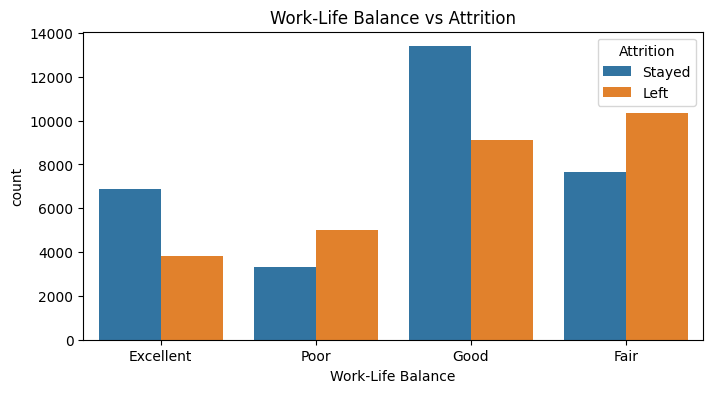

In [20]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=train_df,
    x='Work-Life Balance',
    hue='Attrition'
)

plt.title('Work-Life Balance vs Attrition')
plt.show()

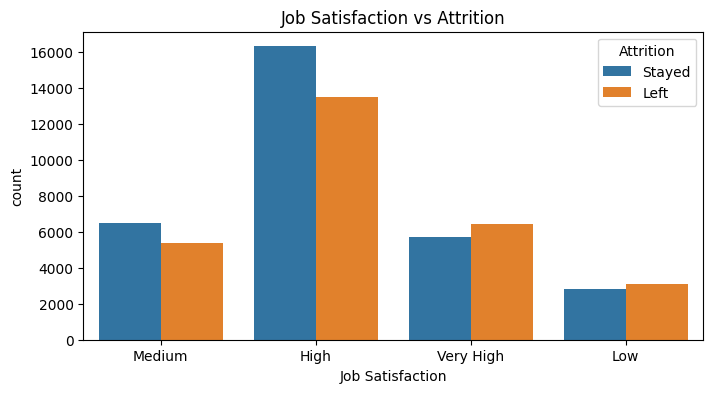

In [21]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=train_df,
    x='Job Satisfaction',
    hue='Attrition'
)

plt.title('Job Satisfaction vs Attrition')
plt.show()

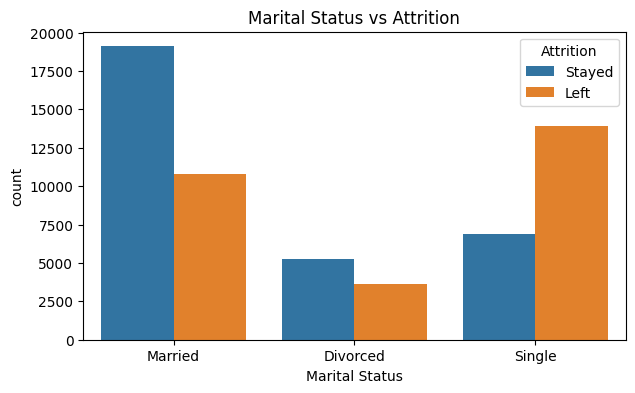

In [22]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=train_df,
    x='Marital Status',
    hue='Attrition'
)

plt.title('Marital Status vs Attrition')
plt.show()

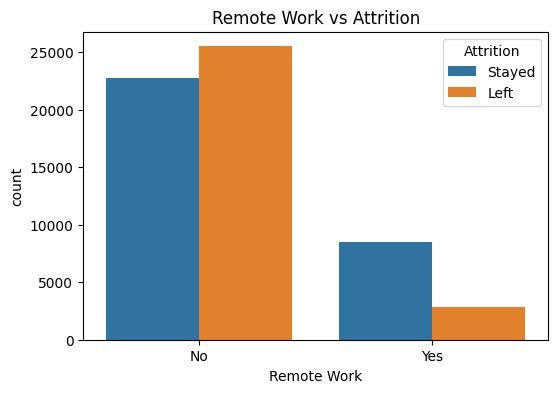

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Remote Work',
    hue='Attrition'
)

plt.title('Remote Work vs Attrition')
plt.show()

# Heatmap (Confusion Matrix)

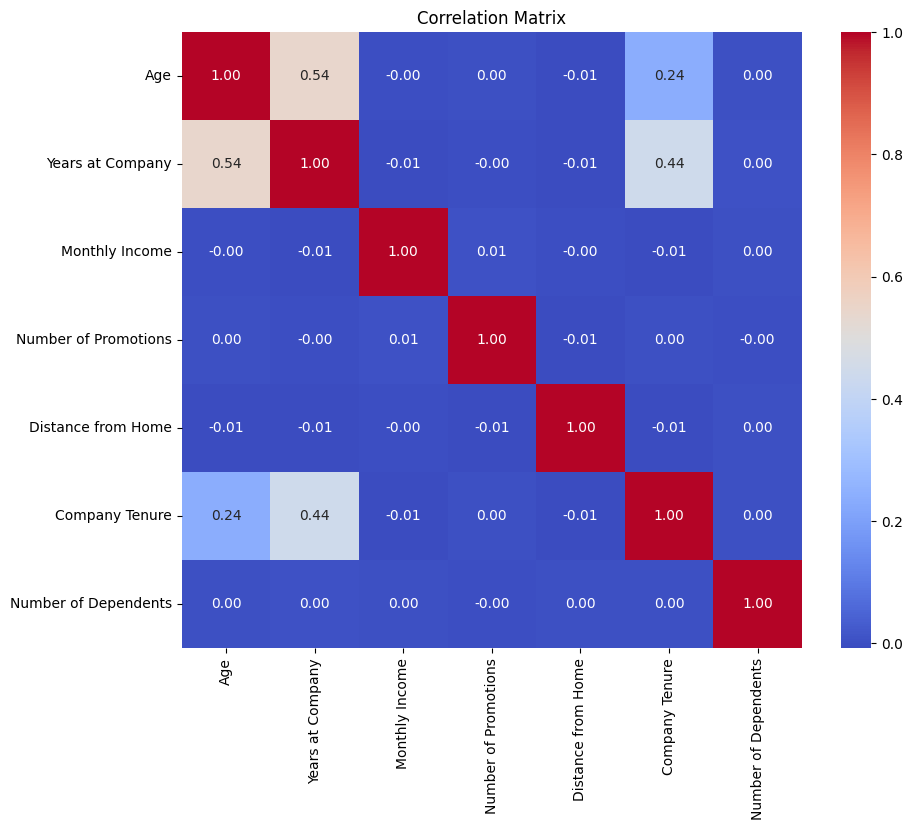

In [24]:
plt.figure(figsize=(10,8))

corr = train_df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing

## Drop "Employee ID" Feature

In [25]:
X_train = train_df.drop(columns=['Employee ID', 'Attrition'])
y_train = train_df['Attrition']

In [26]:
X_test = test_df.drop(columns=['Employee ID', 'Attrition'])
y_test = test_df['Attrition']

## Normalize Numerical Features

In [27]:
scaler = StandardScaler()

In [28]:
X_train_numerical_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_numerical_scaled = scaler.transform(X_test[numerical_cols])

In [29]:
X_train_numerical_scaled_df = pd.DataFrame(X_train_numerical_scaled, columns=numerical_cols, index=X_train.index)
X_test_numerical_scaled_df = pd.DataFrame(X_test_numerical_scaled, columns=numerical_cols, index=X_test.index)

## Encode Target Variable

In [30]:
target_encoder = LabelEncoder()

In [31]:
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

## Encode Non-Numerical Features

In [32]:
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [33]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

In [34]:
X_train_categorical_encoded = onehot_encoder.fit_transform(X_train[categorical_cols])
X_test_categorical_encoded = onehot_encoder.transform(X_test[categorical_cols])

In [35]:
encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)

In [36]:
X_train_categorical_encoded_df = pd.DataFrame(X_train_categorical_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_categorical_encoded_df = pd.DataFrame(X_test_categorical_encoded, columns=encoded_feature_names, index=X_test.index)

## Merge Numerical and Non-Numerical Data

In [37]:
X_train_scaled = pd.concat([X_train_numerical_scaled_df, X_train_categorical_encoded_df], axis=1)
X_test_scaled = pd.concat([X_test_numerical_scaled_df, X_test_categorical_encoded_df], axis=1)

In [38]:
all_processed_cols = X_train_scaled.columns.union(X_test_scaled.columns)
X_train_scaled = X_train_scaled.reindex(columns=all_processed_cols, fill_value=0)
X_test_scaled = X_test_scaled.reindex(columns=all_processed_cols, fill_value=0)

In [39]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train_scaled: (59598, 56)
X_test_scaled : (14900, 56)
y_train: (59598,)
y_test : (14900,)


In [40]:
X_train_scaled.head()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Company Tenure,Number of Dependents,Gender_Female,Gender_Male,Job Role_Education,...,Innovation Opportunities_No,Innovation Opportunities_Yes,Company Reputation_Excellent,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_High,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,-0.626336,0.288648,-0.888892,1.173308,-0.983891,1.308164,-1.059395,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.691627,-1.045173,-0.821960,2.178351,-1.019020,-1.367856,0.869027,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.205827,-0.511645,0.398153,-0.836777,-1.370314,0.717865,0.869027,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.212414,-0.778409,-1.540084,0.168266,-0.808244,-0.226612,0.226220,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.443273,2.244918,-1.153366,-0.836777,0.737448,0.481746,-1.059395,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# Random Forest Modelling

## Baseline Model

In [41]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [42]:
y_pred = rf.predict(X_test_scaled)

In [43]:
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

# Model Evaluation

## Evaluation Metrics

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7493


In [45]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

Precision: 0.7633


In [46]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.7613


In [47]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7623


In [48]:
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8372


## Confusion Matrix

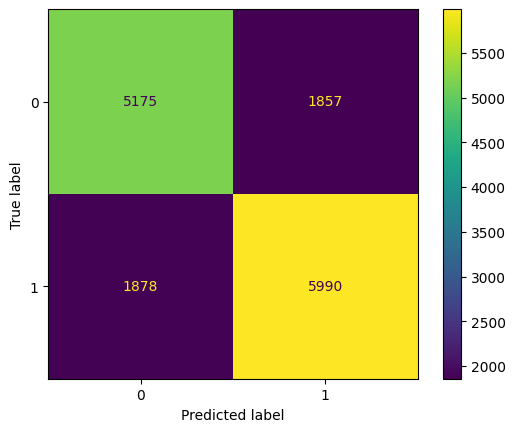

In [49]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## ROC Curve

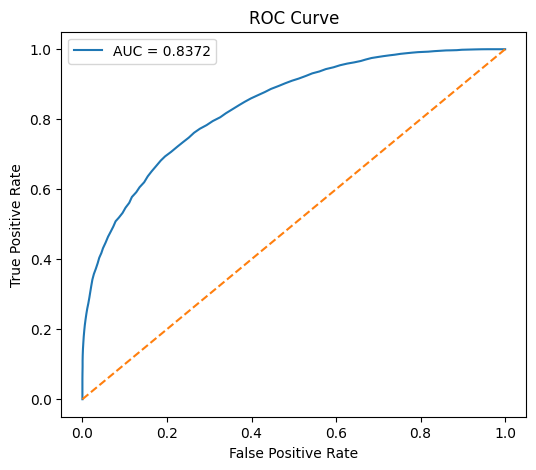

In [50]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

## Classification Report

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.74      0.73      7032
           1       0.76      0.76      0.76      7868

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



# Result Interpretation

## Feature Importance Analysis

In [52]:
importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

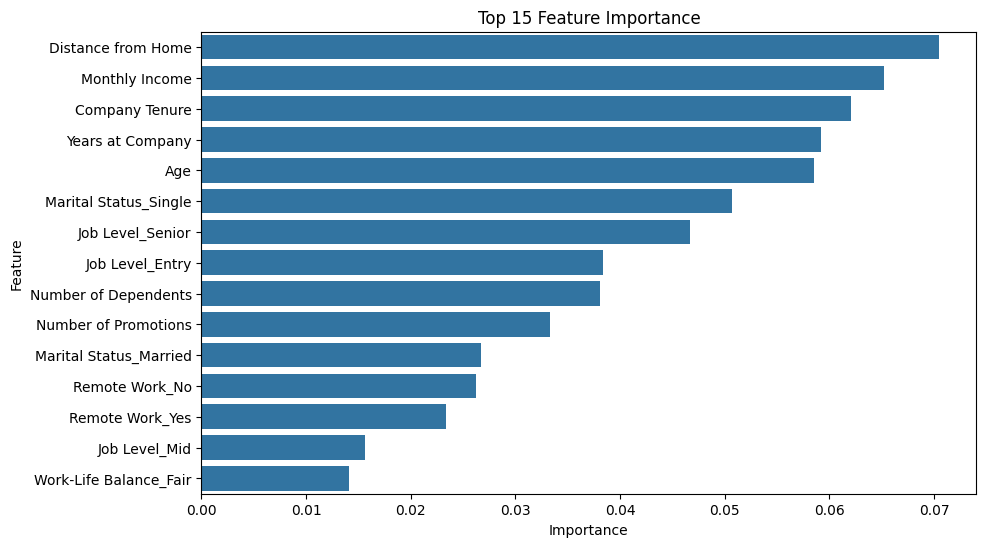

In [53]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importance')
plt.show()

# Hyperparameter Tuning

## Search space

In [54]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [55]:
rf = RandomForestClassifier(
    random_state=42
)

## Randomized Search

In [56]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [57]:
random_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  12.5s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  28.9s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  28.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=  18.6s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  26.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  15.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  15.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimator

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  12.6s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  29.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  12.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  12.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=  18.6s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  26.5s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  26.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=  18.3s
[CV] END max_depth=10, max_feature

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1', verbose=2)

## Best Configuration

In [58]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


In [59]:
print("Best CV F1:")
print(random_search.best_score_)

Best CV F1:
0.7651050225596261


In [60]:
best_rf = random_search.best_estimator_

## Tuned Model Evaluation

In [61]:
y_pred_tuned = best_rf.predict(X_test_scaled)
y_proba_tuned = best_rf.predict_proba(X_test_scaled)[:,1]

In [62]:
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_tuned))

Accuracy : 0.7540268456375839
Precision: 0.7574421168687983
Recall   : 0.7858413828164718
F1 Score : 0.7713804503773938
ROC AUC  : 0.8429638306806333


# Comparison

## Baseline Model VS Tuned Model

In [63]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1','ROC-AUC'],
    'Baseline': [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ],
    'Tuned': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_proba_tuned)
    ]
})

comparison

,Metric,Baseline,Tuned
0,Accuracy,0.749329,0.754027
1,Precision,0.763349,0.757442
2,Recall,0.761312,0.785841
3,F1,0.762329,0.771380
4,ROC-AUC,0.837177,0.842964
